# Depression Awareness Survey — Full Analysis Notebook

Pipeline: Raw CSV → Cleaning → Encoding → Descriptive Statistics → Visualizations

> **How to use:** Place `Contact_Information__Responses__-_Form_Responses_1.csv` in the same folder as this notebook, then run all cells top to bottom.

## 1. Imports

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.labelsize'    : 11,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'figure.dpi'        : 120,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
})

COLORS = ['#378ADD','#534AB7','#D4537E','#D85A30','#1D9E75','#EF9F27','#E24B4A','#639922']
print("Ready.")

Ready.


## 2. Load Raw CSV

In [31]:
RAW_FILE = 'C:/Users/nader/Downloads/Contact Information (Responses) - Form Responses 1.csv'

# Load every column as string to avoid pandas accidentally coercing 'Yes'/'No' or 'TRUE'/'FALSE' into booleans/floats prematurely
df = pd.read_csv(RAW_FILE, dtype=str)
# Strip leading and trailing whitespace from column names to make them easier to match
df.columns = df.columns.str.strip()

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nRaw column names:")
for i, c in enumerate(df.columns):
    print(f"  [{i:02d}] {c}")

Shape: 81 rows × 21 columns

Raw column names:
  [00] Timestamp
  [01] Age
  [02] Country of residence
  [03] Gender
  [04] 1) How often do you feel sad?
  [05] 2) Have you ever had thoughts of hurting yourself or that you would be better off dead?
  [06] 3) Have you ever thought of escaping from home?
  [07] 4) Have you thought about venting to someone about how you feel?
  [08] If yes, can you go into further details?
  [09] 5) Have you got any professional help?
  [10] If yes, can you go into further details?.1
  [11] 6) How likely do you think it is for someone with depression to fully recover with treatment?
  [12] 7) What percentage of people with depression do you believe seek professional help?
  [13] 8) Which age group do you think is at highest risk for having undiagnosed or untreated depression?
  [14] 9) True or false: Men and women have similar rates of developing depression.
  [15] Explain your answer.
  [16] 10) In your opinion, what is the most factor affecting depressi

## 3. Select & Rename Columns
The form exported two trailing columns (a closing message and an empty `@` column) that are not part of the survey data. We keep only the 19 meaningful columns.

In [32]:
KEEP = {
    'Age'                                                                                                : 'age',
    'Country of residence'                                                                               : 'country',
    'Gender'                                                                                             : 'gender',
    '1) How often do you feel sad?'                                                                      : 'sadness_freq',
    '2) Have you ever had thoughts of hurting yourself or that you would be better off dead?'            : 'self_harm_thoughts',
    '3) Have you ever thought of escaping from home?'                                                    : 'escape_thoughts',
    '4) Have you thought about venting to someone about how you feel?'                                   : 'venting',
    'If yes, can you go into further details?'                                                           : 'venting_detail',
    '5) Have you got any professional help?'                                                             : 'professional_help',
    'If yes, can you go into further details?.1'                                                         : 'help_detail',
    '6) How likely do you think it is for someone with depression to fully recover with treatment?'      : 'recovery_likelihood',
    '7) What percentage of people with depression do you believe seek professional help?'                : 'pct_seeking_help',
    '8) Which age group do you think is at highest risk for having undiagnosed or untreated depression?' : 'highest_risk_group',
    '9) True or false: Men and women have similar rates of developing depression.'                        : 'gender_equal_tf',
    'Explain your answer.'                                                                               : 'gender_explanation',
    '10) In your opinion, what is the most factor affecting depression?'                                 : 'main_factor',
    '11)  What describes your current opinions around depression?'                                       : 'opinion',
    '(optional) Do you want to add anything?'                                                            : 'optional_comment',
}

# Create a dictionary of only the columns from KEEP that actually exist in the loaded CSV.
# This prevents KeyError if the form export slightly changed a column name.
existing = {k: v for k, v in KEEP.items() if k in df.columns}
df = df[list(existing.keys())].rename(columns=existing)

# Strip whitespace from every single cell in the dataframe.
# This is safe to apply everywhere because we loaded all columns as strings (dtype=str).
df = df.apply(lambda col: col.str.strip())

print(f"Selected {df.shape[1]} columns:")
print(df.columns.tolist())
df.head(3)

Selected 18 columns:
['age', 'country', 'gender', 'sadness_freq', 'self_harm_thoughts', 'escape_thoughts', 'venting', 'venting_detail', 'professional_help', 'help_detail', 'recovery_likelihood', 'pct_seeking_help', 'highest_risk_group', 'gender_equal_tf', 'gender_explanation', 'main_factor', 'opinion', 'optional_comment']


,age,country,gender,sadness_freq,self_harm_thoughts,escape_thoughts,venting,venting_detail,professional_help,help_detail,recovery_likelihood,pct_seeking_help,highest_risk_group,gender_equal_tf,gender_explanation,main_factor,opinion,optional_comment
0,13-19,Ksa,Female,Often,No,Yes,No,NaN,No,NaN,Somewhat likely,50-75%,Teenagers,TRUE,NaN,Stress and pressure,..,NaN
1,13-19,KSA,Female,Often,No,Yes,Yes,Sometimes when it gets too o overwhelming or w...,Yes,My relative is a psychologist while she's not ...,Somewhat likely,25-50%,Young adults,TRUE,While both have an equal chance of developing ...,"Puberty, Social standards, school stress, no f...",Personally I used to be severally depressed wh...,Already did xxx
2,13-19,Saudi Arabia,Female,Often,No,No,Yes,Sometimes when am fed up with what’s going on ...,No,.,Somewhat likely,Less than 25%,Teenagers,FALSE,They got different reasons and point of views,Social media,A phase .,NaN


## 4. Data Cleaning
### 4.1 Normalise country names
The free-text country field has many variants of the same country (capitalisation differences, trailing spaces, Arabic names, abbreviations). We map them all to a consistent value.

In [ ]:
country_map = {
    # Egypt variants
    'egypt': 'Egypt', 'egypt ': 'Egypt', 'Egypt ': 'Egypt', 'EGyPt': 'Egypt',
    'Cairo': 'Egypt', 'Cairo ': 'Egypt', 'cairo': 'Egypt', 'Cairo,Egypt': 'Egypt',
    '\u0627\u0645 \u0627\u0644\u062f\u0646\u064a\u0627': 'Egypt',
    '\u0627\u0645 \u0627\u0644\u062f\u0646\u064a\u0627 ': 'Egypt',
    # Saudi Arabia variants
    'KSA': 'Saudi Arabia', 'KSA ': 'Saudi Arabia', 'Ksa': 'Saudi Arabia',
    'saudi arabia': 'Saudi Arabia', 'Saudi Arabia ': 'Saudi Arabia',
    'Saudi arabia': 'Saudi Arabia', ' Saudi Arabia': 'Saudi Arabia',
    # Kuwait
    'Kuwait ': 'Kuwait', 'kuwait': 'Kuwait',
    # UAE
    'uae': 'UAE',
    # Australia
    'Australia ': 'Australia',
    # Unknown / ambiguous
    '-': 'Unknown', 'Unknown better': 'Unknown', 'Not settled in yet': 'Unknown',
}
df['country'] = df['country'].replace(country_map)

known = ['Egypt','Saudi Arabia','Kuwait','UAE','Qatar','Canada','Australia','Unknown']
# ~df['country'].isin(known) creates a boolean mask of rows where the country is NOT in the 'known' list.
# We replace those rare or ambiguous entries with 'Unknown'.

df.loc[~df['country'].isin(known), 'country'] = 'Unknown'

print("Country counts after normalisation:")
print(df['country'].value_counts().to_string())

Country counts after normalisation:
country
Egypt           58
Saudi Arabia    12
Kuwait           4
Unknown          3
Qatar            1
Australia        1
UAE              1
Canada           1


### 4.2 Check expected values in closed questions

In [34]:
checks = {
    'gender'             : ['Female', 'Male'],
    'sadness_freq'       : ['Sometimes', 'Often', 'Frequently', 'Usually'],
    'self_harm_thoughts' : ['Yes', 'No'],
    'escape_thoughts'    : ['Yes', 'No'],
    'venting'            : ['Yes', 'No'],
    'professional_help'  : ['Yes', 'No'],
    'recovery_likelihood': ['Very unlikely','Somewhat unlikely','Somewhat likely','Very likely'],
    'pct_seeking_help'   : ['Less than 25%','25-50%','50-75%','More than 75%'],
    'highest_risk_group' : ['Teenagers','Young adults','Middle-aged adults','Senior citizens'],
    'gender_equal_tf'    : ['TRUE','FALSE',''],
}

all_ok = True
for col, expected in checks.items():
    # Get all unique values in the column, replacing NaN with empty string so set operations don't fail
    actual     = set(df[col].fillna('').unique())
    # Use set difference (-) to find any responses that are not in our manually defined 'expected' list
    unexpected = actual - set(expected)
    if unexpected:
        print(f"  WARN  {col}: unexpected values → {unexpected}")
        all_ok = False
    else:
        print(f"  OK    {col}")

if all_ok:
    print("\nAll closed-question columns look clean.")

  OK    gender
  OK    sadness_freq
  OK    self_harm_thoughts
  OK    escape_thoughts
  OK    venting
  OK    professional_help
  OK    recovery_likelihood
  OK    pct_seeking_help
  OK    highest_risk_group
  OK    gender_equal_tf

All closed-question columns look clean.


### 4.3 Ordinal & binary encoding
Ordinal Likert columns are mapped to integers so that mean, median, and standard deviation can be computed. Yes/No columns are mapped to 1/0.

In [35]:
# Sadness frequency  →  1 (Sometimes) … 4 (Usually)
sadness_map = {'Sometimes': 1, 'Often': 2, 'Frequently': 3, 'Usually': 4}
df['sadness_num'] = df['sadness_freq'].map(sadness_map)

# Recovery likelihood  →  1 (Very unlikely) … 4 (Very likely)
recovery_map = {'Very unlikely': 1, 'Somewhat unlikely': 2, 'Somewhat likely': 3, 'Very likely': 4}
df['recovery_num'] = df['recovery_likelihood'].map(recovery_map)

# Encode Yes / No questions into binary 1 / 0 format for statistical operations (like calculating percentages)
# `(df[col] == 'Yes')` creates a boolean series (True/False), and `.astype(int)` turns True into 1 and False into 0.
for col in ['self_harm_thoughts', 'escape_thoughts', 'venting', 'professional_help']:
    df[col + '_bin'] = (df[col] == 'Yes').astype(int)

print("Encoding complete. New numeric columns:")
df[['sadness_num','recovery_num',
    'self_harm_thoughts_bin','escape_thoughts_bin',
    'venting_bin','professional_help_bin']].describe()

Encoding complete. New numeric columns:


,sadness_num,recovery_num,self_harm_thoughts_bin,escape_thoughts_bin,venting_bin,professional_help_bin
count,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000
mean,2.456790,3.012346,0.641975,0.518519,0.691358,0.111111
std,1.215004,0.661321,0.482407,0.502770,0.464811,0.316228
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,3.000000,1.000000,1.000000,1.000000,0.000000
75%,4.000000,3.000000,1.000000,1.000000,1.000000,0.000000
max,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000


### 4.4 Export clean dataset

In [36]:
df.to_csv('depression_survey_clean.csv', index=False)
print(f"Saved: depression_survey_clean.csv  ({df.shape[0]} rows, {df.shape[1]} columns)")

Saved: depression_survey_clean.csv  (81 rows, 24 columns)


## 5. Descriptive Statistics

In [ ]:
def report(series, label, original_col=None):
    s = series.dropna()
    # mode() returns a Series because there can be multiple modes (ties). 
    # .iloc[0] safely extracts just the first mode value to display.
    mode_val = s.mode().iloc[0] if original_col is None else df[original_col].mode().iloc[0]
    print(f"{'─'*48}")
    print(f" {label}")
    print(f"{'─'*48}")
    print(f"  n        = {len(s)}")
    print(f"  Mean     = {s.mean():.2f}")
    print(f"  Median   = {s.median():.2f}")
    print(f"  Mode     = {mode_val}")
    print(f"  Std Dev  = {s.std():.2f}")
    print(f"  Min / Max = {s.min()} / {s.max()}")
    print()

report(df['sadness_num'],   'Sadness frequency  (1=Sometimes … 4=Usually)', 'sadness_freq')
report(df['recovery_num'],  'Recovery likelihood  (1=Very unlikely … 4=Very likely)', 'recovery_likelihood')

print(f"{'─'*48}")
print(" Binary variables (Yes = 1)")
print(f"{'─'*48}")
for col, label in [
    ('self_harm_thoughts_bin', 'Self-harm thoughts'),
    ('escape_thoughts_bin',    'Escape thoughts'),
    ('venting_bin',            'Wanted to vent'),
    ('professional_help_bin',  'Got professional help'),
]:
    yes = df[col].sum()
    pct = df[col].mean() * 100
    print(f"  {label:30s}  Yes={yes:2d} ({pct:.1f}%)   No={len(df)-yes:2d} ({100-pct:.1f}%)")

────────────────────────────────────────────────
 Sadness frequency  (1=Sometimes … 4=Usually)
────────────────────────────────────────────────
  n        = 81
  Mean     = 2.46
  Median   = 2.00
  Mode     = Sometimes
  Std Dev  = 1.22
  Min / Max = 1 / 4

────────────────────────────────────────────────
 Recovery likelihood  (1=Very unlikely … 4=Very likely)
────────────────────────────────────────────────
  n        = 81
  Mean     = 3.01
  Median   = 3.00
  Mode     = Somewhat likely
  Std Dev  = 0.66
  Min / Max = 1 / 4

────────────────────────────────────────────────
 Binary variables (Yes = 1)
────────────────────────────────────────────────
  Self-harm thoughts              Yes=52 (64.2%)   No=29 (35.8%)
  Escape thoughts                 Yes=42 (51.9%)   No=39 (48.1%)
  Wanted to vent                  Yes=56 (69.1%)   No=25 (30.9%)
  Got professional help           Yes= 9 (11.1%)   No=72 (88.9%)


### Summary table

In [38]:
summary = pd.DataFrame({
    'Variable': [
        'Sadness frequency (encoded 1–4)',
        'Recovery likelihood (encoded 1–4)',
        'Self-harm thoughts  (% Yes)',
        'Escape thoughts  (% Yes)',
        'Wanted to vent  (% Yes)',
        'Got professional help  (% Yes)',
    ],
    'n': [
        df['sadness_num'].count(), df['recovery_num'].count(),
        len(df), len(df), len(df), len(df),
    ],
    'Mean / %': [
        f"{df['sadness_num'].mean():.2f}",
        f"{df['recovery_num'].mean():.2f}",
        f"{df['self_harm_thoughts_bin'].mean()*100:.1f}%",
        f"{df['escape_thoughts_bin'].mean()*100:.1f}%",
        f"{df['venting_bin'].mean()*100:.1f}%",
        f"{df['professional_help_bin'].mean()*100:.1f}%",
    ],
    'Median': [
        df['sadness_num'].median(), df['recovery_num'].median(),
        '—','—','—','—',
    ],
    'Mode': [
        df['sadness_freq'].mode().iloc[0],
        df['recovery_likelihood'].mode().iloc[0],
        'Yes','Yes','Yes','No',
    ],
})
summary

,Variable,n,Mean / %,Median,Mode
0,Sadness frequency (encoded 1–4),81,2.46,2.0,Sometimes
1,Recovery likelihood (encoded 1–4),81,3.01,3.0,Somewhat likely
2,Self-harm thoughts (% Yes),81,64.2%,—,Yes
3,Escape thoughts (% Yes),81,51.9%,—,Yes
4,Wanted to vent (% Yes),81,69.1%,—,Yes
5,Got professional help (% Yes),81,11.1%,—,No


## 6. Visualizations

### 6.1 Sadness Frequency Distribution

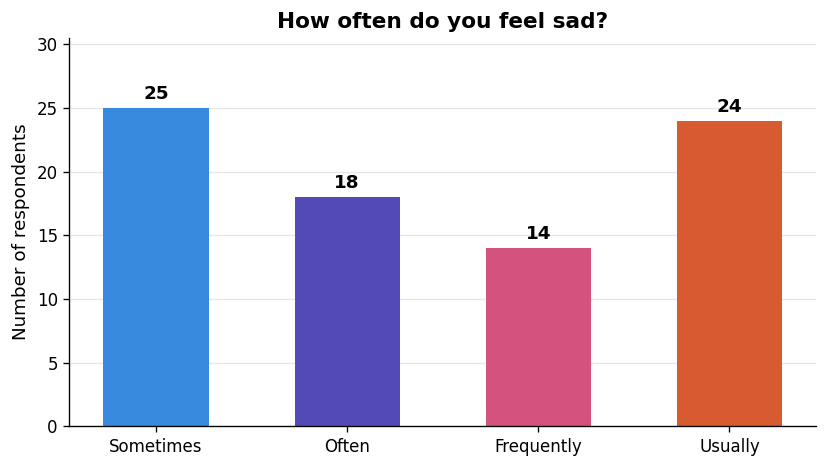

In [39]:
fig, ax = plt.subplots(figsize=(7, 4))
order = ['Sometimes', 'Often', 'Frequently', 'Usually']
# reindex(order) ensures the bars are plotted in our logical order of frequency, rather than sorting by value counts
counts = df['sadness_freq'].value_counts().reindex(order)
# zorder=2 ensures the bars are drawn on top of the grid lines (which have zorder=1)
bars = ax.bar(order, counts.values, color=COLORS[:4], width=0.55, zorder=2)
ax.grid(axis='y', alpha=0.3, zorder=1)
ax.set_ylabel('Number of respondents')
ax.set_title('How often do you feel sad?')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0, counts.max() * 1.22)
plt.tight_layout(); plt.show()

### 6.2 Yes / No Responses — Key Questions

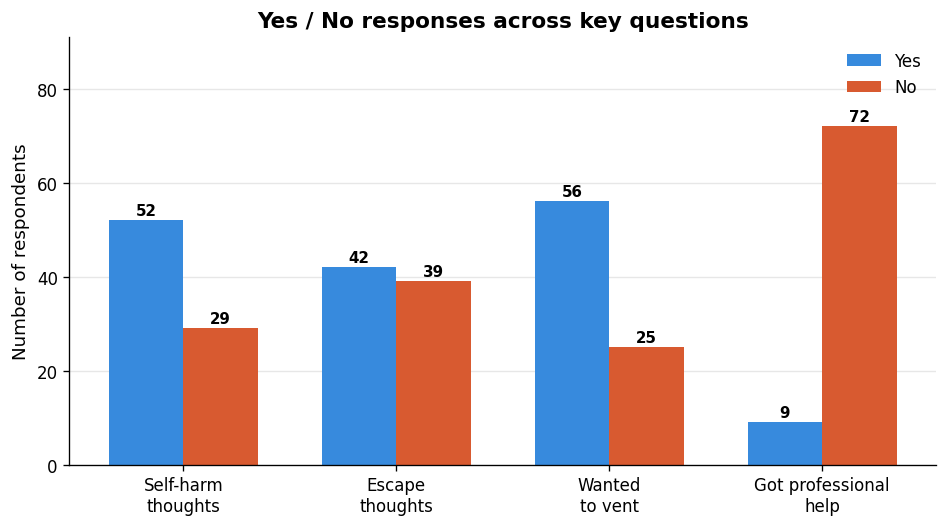

In [40]:
fig, ax = plt.subplots(figsize=(8, 4.5))
labels    = ['Self-harm\nthoughts', 'Escape\nthoughts', 'Wanted\nto vent', 'Got professional\nhelp']
yes_vals  = [df['self_harm_thoughts_bin'].sum(), df['escape_thoughts_bin'].sum(),
             df['venting_bin'].sum(),            df['professional_help_bin'].sum()]
no_vals   = [len(df) - y for y in yes_vals]
x = np.arange(len(labels)); w = 0.35
b1 = ax.bar(x - w/2, yes_vals, w, label='Yes', color='#378ADD', zorder=2)
b2 = ax.bar(x + w/2, no_vals,  w, label='No',  color='#D85A30', zorder=2)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Number of respondents')
ax.set_title('Yes / No responses across key questions')
ax.legend(framealpha=0); ax.grid(axis='y', alpha=0.3, zorder=1)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylim(0, len(df) + 10)
plt.tight_layout(); plt.show()

### 6.3 Perceived Recovery Likelihood

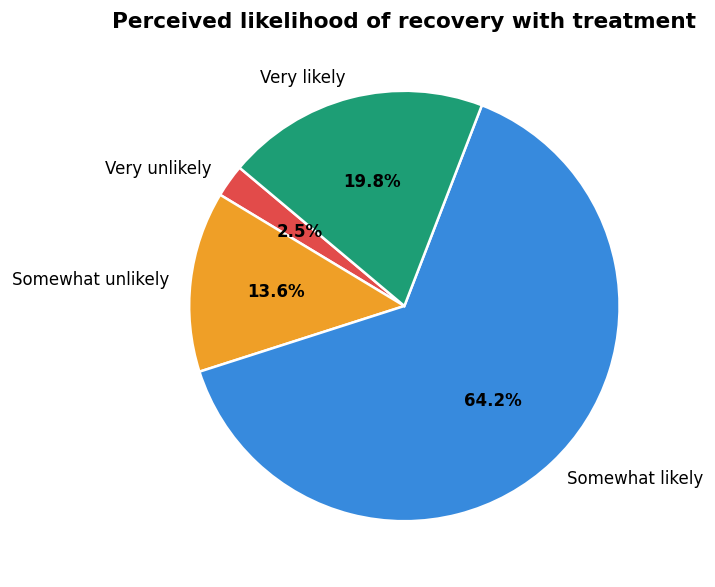

In [41]:
fig, ax = plt.subplots(figsize=(6, 5))
order3   = ['Very unlikely', 'Somewhat unlikely', 'Somewhat likely', 'Very likely']
counts3  = df['recovery_likelihood'].value_counts().reindex(order3).fillna(0).astype(int)
wedge_c  = ['#E24B4A', '#EF9F27', '#378ADD', '#1D9E75']
wedges, texts, autotexts = ax.pie(
    counts3.values, labels=order3, autopct='%1.1f%%', colors=wedge_c,
    startangle=140, wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'},
    textprops={'fontsize': 10}
)
for at in autotexts: at.set_fontweight('bold')
ax.set_title('Perceived likelihood of recovery with treatment')
plt.tight_layout(); plt.show()

### 6.4 Estimated % of People Who Seek Help

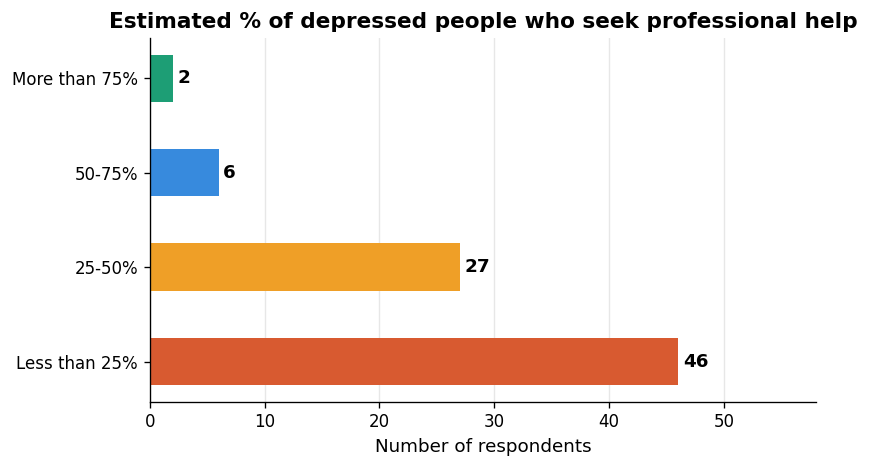

In [42]:
fig, ax = plt.subplots(figsize=(7, 4))
order4  = ['Less than 25%', '25-50%', '50-75%', 'More than 75%']
counts4 = df['pct_seeking_help'].value_counts().reindex(order4).fillna(0).astype(int)
bars4   = ax.barh(order4, counts4.values,
                  color=['#D85A30','#EF9F27','#378ADD','#1D9E75'], height=0.5, zorder=2)
ax.grid(axis='x', alpha=0.3, zorder=1)
ax.set_xlabel('Number of respondents')
ax.set_title('Estimated % of depressed people who seek professional help')
for bar, val in zip(bars4, counts4.values):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=11, fontweight='bold')
ax.set_xlim(0, counts4.max() + 12)
plt.tight_layout(); plt.show()

### 6.5 Highest-Risk Age Group (Perception)

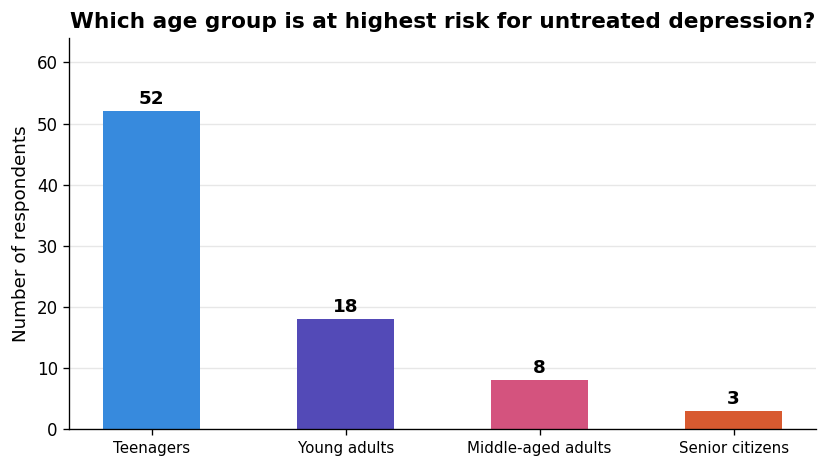

In [43]:
fig, ax = plt.subplots(figsize=(7, 4))
order5  = ['Teenagers', 'Young adults', 'Middle-aged adults', 'Senior citizens']
counts5 = df['highest_risk_group'].value_counts().reindex(order5).fillna(0).astype(int)
bars5   = ax.bar(order5, counts5.values, color=COLORS[:4], width=0.5, zorder=2)
ax.grid(axis='y', alpha=0.3, zorder=1)
ax.set_ylabel('Number of respondents')
ax.set_title('Which age group is at highest risk for untreated depression?')
for bar, val in zip(bars5, counts5.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0, counts5.max() + 12); plt.xticks(fontsize=9)
plt.tight_layout(); plt.show()

### 6.6 Gender Distribution

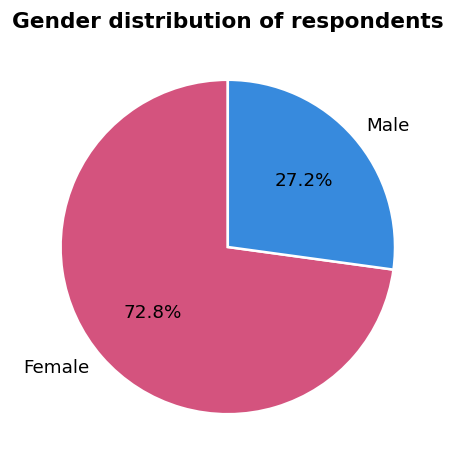

In [44]:
fig, ax = plt.subplots(figsize=(5, 4))
gc = df['gender'].value_counts()
ax.pie(gc.values, labels=gc.index, autopct='%1.1f%%',
       colors=['#D4537E','#378ADD'], startangle=90,
       wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'},
       textprops={'fontsize': 11})
ax.set_title('Gender distribution of respondents')
plt.tight_layout(); plt.show()

### 6.7 Country of Residence

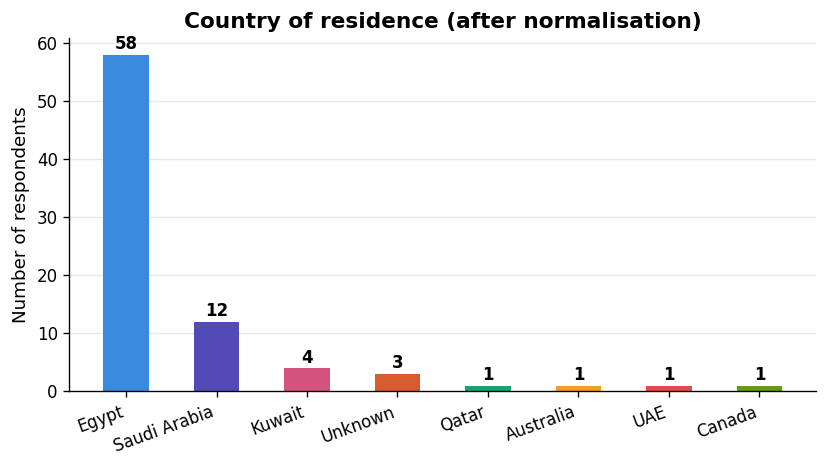

In [45]:
fig, ax = plt.subplots(figsize=(7, 4))
cc   = df['country'].value_counts()
bars7 = ax.bar(cc.index, cc.values, color=COLORS[:len(cc)], width=0.5, zorder=2)
ax.grid(axis='y', alpha=0.3, zorder=1)
ax.set_ylabel('Number of respondents')
ax.set_title('Country of residence (after normalisation)')
for bar, val in zip(bars7, cc.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.xticks(rotation=20, ha='right', fontsize=10)
plt.tight_layout(); plt.show()